#### Implementing Linear Refresion Without Sklearn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("Salary_Data.csv")

In [5]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [6]:
X=df['YearsExperience'].values
y=df['Salary'].values


In [7]:
X

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [8]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872], dtype=int64)

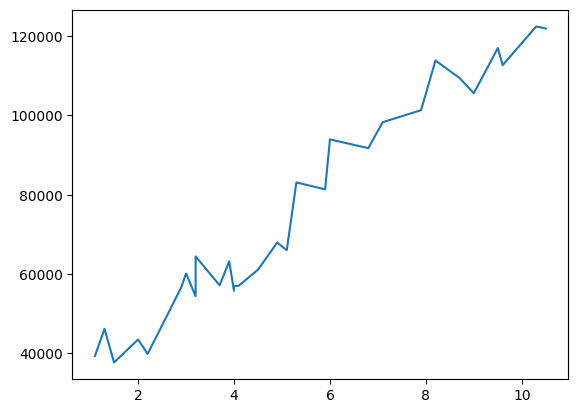

In [10]:
plt.plot(X,y)

In [11]:
X=np.array(X)
y=np.array(y)

In [12]:
def mean(x):
    return np.sum(x)/len(x)


In [13]:
def variance(x):
    m=mean(x)
    return np.sum((x-m)**2)/len(x)

In [14]:
def norm(X):
    m=mean(X)
    v=variance(X)
    return (X-m)/np.sqrt(v)

In [15]:
X_norm=norm(X)

In [16]:
import random

In [34]:
class SimpleLR:
    def __init__(self,lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr=lr
        self.max_iter=max_iter
        self.threshold=threshold
        self.w=random.uniform(-1,1)
        self.b=random.uniform(-1,1)
    def predict(self,X):
        return self.w*X+self.b
    def fit(self,X,y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors= y-y_pred
        prev_loss = (1/(2*n))*np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n)*np.sum(errors*X)
            b_grad = (1/n)*np.sum(errors)
            self.w += self.lr*w_grad
            self.b += self.lr*b_grad
            y_pred = self.predict(X)
            errors= y-y_pred
            curr_loss = (1/(2*n))*np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    
    def plot(self,X,y):
        y_pred=self.predict(X)
        plt.plot(X,y)
        plt.plot(X,y_pred)

In [35]:
model = SimpleLR()

In [36]:
loss_history = model.fit(X_norm,y)

In [37]:
loss_history

[3251429811.5849767,
 2636628887.797447,
 2138640139.5295491,
 1735269253.4325514,
 1408538835.6939828,
 1143887197.3257432,
 929519370.2474686,
 755881430.3140663,
 615234698.9680103,
 501310846.5777049,
 409032526.14155775,
 334287086.5882786,
 273743280.55012226,
 224702797.65921578,
 184980006.51758146,
 152804545.69285765,
 126742422.42483139,
 105632102.57773012,
 88532743.50157811,
 74682262.64989497,
 63463373.16003154,
 54376072.67324225,
 47015359.27894287,
 41053181.429560445,
 36223817.37156067,
 32312032.48458084,
 29143486.726127177,
 26576964.661779724,
 24498081.789658293,
 22814186.663239896,
 21450231.610841032,
 20345428.01839794,
 19450537.108519018,
 18725675.47151711,
 18138537.545545537,
 17662955.825508576,
 17277734.632278632,
 16965705.46576238,
 16712961.840884222,
 16508239.504732922,
 16342414.412450345,
 16208096.087701466,
 16099298.244654896,
 16011171.99178715,
 15939789.726964282,
 15881970.092457771,
 15835136.188507479,
 15797200.726307752,
 15766473

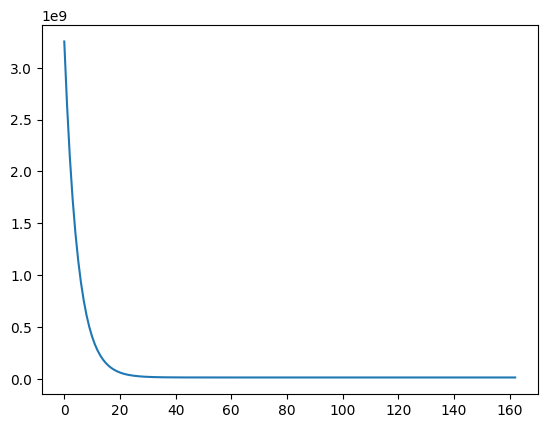

In [38]:
plt.plot(loss_history)

In [ ]:
from sklear